# 08 — From Dynamic Programming to Reinforcement Learning

## Cost-to-go functions, Bellman operators, and what MPC, LMPC and Q-learning approximate

Every controller in this series rests on one object, the **optimal cost-to-go** $J^\star(x)$: the
cost of acting optimally from $x$ onward. Dynamic programming (DP) computes it for every state. MPC
approximates it online, at the current state, with a finite horizon and a terminal cost $V_f$ on a
terminal set $\mathcal X_f$. LMPC learns $V_f$ from its own trajectories. Reinforcement learning (RL)
estimates $J^\star$, or its state-input version $Q^\star$, from sampled transitions. All four rest on

$$
\boxed{
J_k(x)=\min_{u}\Big\{q(x,u)+J_{k+1}\big(f(x,u)\big)\Big\}
}
$$

and on its infinite-horizon fixed point.

## Learning objectives

After completing this notebook, you should be able to:

1. derive the DP recursion from the principle of optimality, with constraints as infinite costs,
   and the Riccati recursion as its linear-quadratic case;
2. prove that the Bellman operator is a $\gamma$-contraction, state what the proof assumes, and
   implement value and policy iteration;
3. relate the domain of $J^\star$ to the invariant sets of notebook 02 and quantify the curse of
   dimensionality;
4. interpret MPC as truncated DP, and the stored costs-to-go of LMPC as upper bounds of $J^\star$;
5. derive tabular Q-learning and explain what changes with function approximation (DQN).

In [1]:
from pathlib import Path
import sys
import itertools
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

from advanced_mpc_lmpc.linear import dlqr
from advanced_mpc_lmpc.polytopes import (
    HPolytope,
    closed_loop_admissible_set_scalar_input,
    maximal_control_invariant,
    maximal_invariant,
)
from advanced_mpc_lmpc.plotting import plot_polytope

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
})

## Table of Contents

- **[Part I — Bellman's principle of optimality](#part-1)** — I.1 The finite-horizon problem · I.2 The principle of optimality · I.3 The DP recursion · I.4 A first computation
- **[Part II — The linear-quadratic case](#part-2)** — II.1 Quadratic cost-to-go is preserved · II.2 Why the Riccati recursion converges · II.3 The double integrator
- **[Part III — Infinite horizon: the Bellman operator](#part-3)** — III.1 The Bellman equation · III.2 $T$ is a $\gamma$-contraction · III.3 Consequences · III.4 A finite test problem · III.5 Value iteration · III.6 Policy iteration
- **[Part IV — The constrained double integrator](#part-4)** — IV.1 Hard constraints without discount · IV.2 The cost-to-go landscape · IV.3 The domain of $J^\star$ · IV.4 The curse of dimensionality
- **[Part V — Where MPC and LMPC fit](#part-5)** — V.1 MPC is truncated DP · V.2 What a good terminal cost buys · V.3 Terminal ingredients compared · V.4 LMPC learns an upper bound
- **[Part VI — Model-free: Q-functions and Q-learning](#part-6)** — VI.1 The Q-function · VI.2 Tabular Q-learning · VI.3 Q-learning on the lattice · VI.4 Function approximation and DQN
- **[Part VII — Common pitfalls](#part-7)**
- **[Part VIII — Check your understanding](#part-8)**
- **[Part IX — Summary and references](#part-9)**

<a id="part-1"></a>
# Part I — Bellman's principle of optimality

## I.1 The finite-horizon problem

For $x_{k+1}=f(x_k,u_k)$ with constraints $x_k\in\mathcal X$, $u_k\in\mathcal U$ and
$x_N\in\mathcal X_f$, an input sequence $\mathbf u=(u_0,\ldots,u_{N-1})$ costs

$$
J(x_0;\mathbf u)=\sum_{k=0}^{N-1}q(x_k,u_k)+V_f(x_N).
$$

Fold the constraints into the costs: $\bar q(x,u)=q(x,u)$ if $x\in\mathcal X$ and $u\in\mathcal U$,
and $+\infty$ otherwise; $\bar V_f(x)=V_f(x)$ on $\mathcal X_f$ and $+\infty$ otherwise. A sequence is
admissible exactly when its extended cost is finite. The **tail problem** at stage $k$ optimizes the
remaining inputs from $x_k=x$:

$$
J_k^\star(x)=\min_{u_k,\ldots,u_{N-1}}\Big[\sum_{i=k}^{N-1}\bar q(x_i,u_i)+\bar V_f(x_N)\Big],
\qquad J_N^\star=\bar V_f .
$$

We assume the minima are attained, which is automatic for a finite $\mathcal U$ as in all
computations below (otherwise read $\inf$).

## I.2 The principle of optimality

> **Principle of optimality (Bellman).** If $\mathbf u^\star$ is optimal from $x_0$, with
> $J_0^\star(x_0)<\infty$ and trajectory $x_0^\star,\ldots,x_N^\star$, then for every $k$ the tail
> $(u_k^\star,\ldots,u_{N-1}^\star)$ is optimal for the tail problem from $x_k^\star$.

*Proof.* If a tail from $x_k^\star$ were strictly cheaper, splicing it onto the head
$(u_0^\star,\ldots,u_{k-1}^\star)$ would give an admissible sequence (the head still reaches
$x_k^\star$, and each constraint involves a single stage) with strictly lower total cost. $\square$

The proof uses an **additive** cost and a state that **summarizes the past**. A constraint coupling
all stages, such as $\sum_k\|u_k\|^2\le E$, breaks the principle until the state is augmented with
the remaining budget.

## I.3 The dynamic-programming recursion

Split the minimization into the first input and the tail. The first stage cost does not depend on
the tail inputs, and the tail problem depends on $u_k$ only through $x_{k+1}=f(x,u_k)$:

$$
\begin{aligned}
J_k^\star(x)
&=\min_{u_k}\Big[\bar q(x,u_k)+\min_{u_{k+1},\ldots,u_{N-1}}
\Big(\sum_{i=k+1}^{N-1}\bar q(x_i,u_i)+\bar V_f(x_N)\Big)\Big]\\
&=\min_{u_k}\Big[\bar q(x,u_k)+J_{k+1}^\star\big(f(x,u_k)\big)\Big].
\end{aligned}
$$

This is the **DP recursion**

$$
\boxed{
J_N=\bar V_f,
\qquad
J_k(x)=\min_{u}\Big\{\bar q(x,u)+J_{k+1}\big(f(x,u)\big)\Big\},
\quad k=N-1,\ldots,0,
}
$$

and any minimizer $\mu_k(x)$ is an optimal **feedback law**. (By backward induction, every input
sequence from $x$ at stage $k$ costs at least $J_k(x)$, and $\mu_k,\mu_{k+1},\ldots$ attains it.)

If $q$ is finite on $\mathcal X\times\mathcal U$, the **feasible sets** follow
$\operatorname{dom}J_k=\mathcal X\cap\operatorname{Pre}(\operatorname{dom}J_{k+1})$,
$\operatorname{dom}J_N=\mathcal X_f$: the recursion of notebook 02 for the $(N-k)$-step controllable
set $\mathcal K_{N-k}(\mathcal X_f)$, that is, DP applied to functions with values in $\{0,+\infty\}$.

## I.4 A first computation

Integer positions $x\in\{-10,\ldots,10\}$, moves $u\in\{-2,\ldots,2\}$, $x^+=x+u$,
$q(x,u)=x^2+u^2$, $N=5$ and the terminal constraint $x_N=0$. The code checks DP against enumeration
of all $5^5$ input sequences.

input sequences per initial state: 3125
same feasible states: True
max |J_DP - J_brute|: 0.0
stage-cost evaluations, brute force: 328125
stage-cost evaluations, DP: 525
k=0: dom J_k = {-10,...,10}
k=1: dom J_k = {-8,...,8}
k=2: dom J_k = {-6,...,6}
k=3: dom J_k = {-4,...,4}
k=4: dom J_k = {-2,...,2}
k=5: dom J_k = {0,...,0}
J_0(x) for x = 0,...,10: [  0.   2.   7.  15.  27.  44.  67.  97. 135. 182. 240.]
mu_k(2) for k = 0,...,4: [-1.0, -1.0, -1.0, -1.0, -2.0]


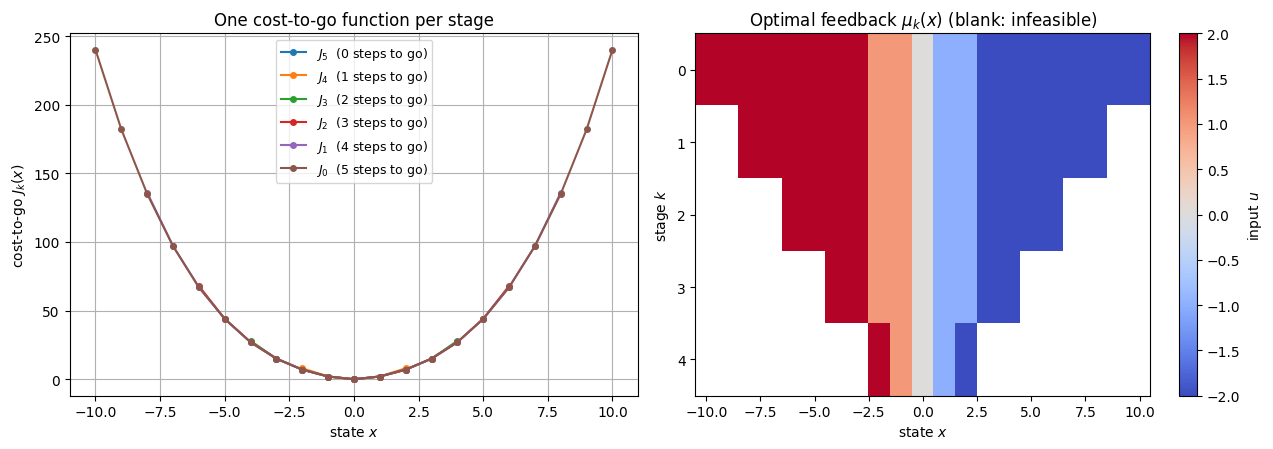

In [2]:
# Integer chain: x+ = x + u, |x| <= 10, u in {-2,...,2}, terminal constraint x_N = 0.
x_chain = np.arange(-10, 11)
u_chain = np.arange(-2, 3)
N_chain = 5

x_next = x_chain[:, None] + u_chain[None, :]
admissible = np.abs(x_next) <= 10
succ_chain = np.clip(x_next, -10, 10) + 10          # index of the successor state
q_chain = np.where(admissible, x_chain[:, None] ** 2 + u_chain[None, :] ** 2, np.inf)

J_chain = [None] * (N_chain + 1)
mu_chain = [None] * N_chain
J_chain[N_chain] = np.where(x_chain == 0, 0.0, np.inf)        # bar V_f
for k in range(N_chain - 1, -1, -1):
    Qk = q_chain + J_chain[k + 1][succ_chain]                 # q(x,u) + J_{k+1}(f(x,u))
    J_chain[k] = Qk.min(axis=1)
    mu_chain[k] = np.where(np.isfinite(J_chain[k]), u_chain[Qk.argmin(axis=1)], np.nan)

# Brute force: every input sequence from every initial state.
seqs = np.array(list(itertools.product(u_chain, repeat=N_chain)))
xs = np.tile(x_chain.astype(float), (len(seqs), 1))
cost = np.zeros_like(xs)
for k in range(N_chain):
    u = seqs[:, [k]]
    cost += xs ** 2 + u ** 2
    xs = xs + u
    cost[np.abs(xs) > 10] = np.inf
cost[xs != 0] = np.inf
J_brute = cost.min(axis=0)

fin = np.isfinite(J_brute)
print("input sequences per initial state:", len(seqs))
print("same feasible states:", np.array_equal(fin, np.isfinite(J_chain[0])))
print("max |J_DP - J_brute|:", np.max(np.abs(J_chain[0][fin] - J_brute[fin])))
print("stage-cost evaluations, brute force:", N_chain * len(seqs) * len(x_chain))
print("stage-cost evaluations, DP:", N_chain * len(x_chain) * len(u_chain))
for k in range(N_chain + 1):
    d = x_chain[np.isfinite(J_chain[k])]
    print(f"k={k}: dom J_k = {{{d.min()},...,{d.max()}}}")
print("J_0(x) for x = 0,...,10:", J_chain[0][10:])
print("mu_k(2) for k = 0,...,4:", [float(mu_chain[k][12]) for k in range(N_chain)])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
for k in range(N_chain, -1, -1):
    ax.plot(x_chain, J_chain[k], "o-", ms=4, label=f"$J_{k}$  ({N_chain - k} steps to go)")
ax.set_xlabel("state $x$")
ax.set_ylabel("cost-to-go $J_k(x)$")
ax.set_title("One cost-to-go function per stage")
ax.legend(fontsize=9)
ax = axes[1]
im = ax.imshow(np.array(mu_chain), aspect="auto", cmap="coolwarm", vmin=-2, vmax=2,
               extent=[x_chain[0] - 0.5, x_chain[-1] + 0.5, N_chain - 0.5, -0.5])
ax.set_xlabel("state $x$")
ax.set_ylabel("stage $k$")
ax.set_title(r"Optimal feedback $\mu_k(x)$ (blank: infeasible)")
ax.grid(False)
fig.colorbar(im, ax=ax, label="input $u$")
plt.tight_layout()
plt.show()

**Reading the result.** DP and enumeration agree on every state, including the infeasible ones, but
DP needs 525 stage-cost evaluations instead of 328,125: linear rather than exponential in $N$. The
domains are the controllable sets $|x|\le2(N-k)$. The policy is **time-varying**: from $x=2$ the
optimal move is $-1$ while two or more steps remain, but $-2$ at $k=4$.

DP used no linearity or convexity, only evaluations of $f$ and $q$; its price is a table over all
states. The ways out are structure (Part II), optimization at the current state only (MPC, Part V),
and estimation from samples (Part VI).

<a id="part-2"></a>
# Part II — The linear-quadratic case

## II.1 Quadratic cost-to-go is preserved by the Bellman step

Let $f(x,u)=Ax+Bu$, $q(x,u)=x^\top Qx+u^\top Ru$ with $Q\succeq0$ and $R\succ0$,
$V_f(x)=x^\top P_fx$, and no constraints. If $J_{k+1}(x)=x^\top P_{k+1}x$, completing the square
gives

$$
\varphi(u)=x^\top Qx+u^\top Ru+(Ax+Bu)^\top P_{k+1}(Ax+Bu)
=(u+K_kx)^\top H_k(u+K_kx)+x^\top P_kx,
$$

with $H_k=R+B^\top P_{k+1}B\succ0$, $K_k=H_k^{-1}B^\top P_{k+1}A$ and

$$
\boxed{
P_k=Q+A^\top P_{k+1}A-A^\top P_{k+1}B\,(R+B^\top P_{k+1}B)^{-1}B^\top P_{k+1}A .
}
$$

So $\mu_k(x)=-K_kx$ and $J_k(x)=x^\top P_kx$: DP over functions collapses to the **Riccati
recursion** over matrices. Evaluating $\varphi$ at $u=-Kx$ for an arbitrary gain $K$ gives

$$
P_k=Q+K_k^\top RK_k+(A-BK_k)^\top P_{k+1}(A-BK_k)\ \preceq\ Q+K^\top RK+(A-BK)^\top P_{k+1}(A-BK).
\tag{$\star$}
$$

With constraints this structure is lost ($J_k$ becomes piecewise quadratic), which is one reason
MPC optimizes online, for the current state only.

## II.2 Why the Riccati recursion converges

Write $\operatorname{Ric}(X)$ for the boxed map with $P_{k+1}=X$, so that
$P_{N-j}=\operatorname{Ric}^j(P_f)$. Let $P$ be the stabilizing DARE solution, $K$ its gain and
$A_{\mathrm{cl}}=A-BK$; for $X\succeq0$ let $K_X$ be the gain computed from $X$ and $A_X=A-BK_X$.
Applying $(\star)$ twice, once with $P_{k+1}=X$ and the gain $K$, once with $P_{k+1}=P$ and the gain
$K_X$, gives the sandwich

$$
A_X^\top(X-P)A_X\ \preceq\ \operatorname{Ric}(X)-P\ \preceq\ A_{\mathrm{cl}}^\top(X-P)A_{\mathrm{cl}} .
$$

If $P_f\succeq P$, every iterate stays above $P$ and
$\|\operatorname{Ric}^j(P_f)-P\|_2\le\|A_{\mathrm{cl}}^j\|_2^2\,\|P_f-P\|_2$: the error decays at
the rate $\rho(A_{\mathrm{cl}})^2$ per step. From $P_f\preceq P$ the iterates rise toward $P$ at the
same asymptotic rate, since $K_X\to K$: the closed loop propagates the cost-to-go error. ($(A,B)$
stabilizable and $(Q^{1/2},A)$ detectable guarantee the limit from every $P_f\succeq0$.)

## II.3 The double integrator, numerically

We use the double integrator of notebook 02,
$A=\begin{bmatrix}1&1\\0&1\end{bmatrix}$, $B=\begin{bmatrix}0.5\\1\end{bmatrix}$, with the weights
of its LQR terminal set, $Q=\operatorname{diag}(1,0.2)$ and $R=0.2$. The recursion runs from
$P_f\in\{0,Q,10P\}$ and is compared with `dlqr`.

P from dlqr:
 [[1.7042 0.5   ]
 [0.5    0.7021]]
K from dlqr: [0.7396 1.2604]
rho(A_cl) = 0.3308   rho^2 = 0.1094
   $P_f=0$: ||P_(N-25) - P|| = 1.6e-15   max|K_(N-25) - K| = 5.6e-16   mean rate per step, j=2..12: 0.114
   $P_f=Q$: ||P_(N-25) - P|| = 1.6e-15   max|K_(N-25) - K| = 5.6e-16   mean rate per step, j=2..12: 0.112
 $P_f=10P$: ||P_(N-25) - P|| = 1.3e-15   max|K_(N-25) - K| = 4.4e-16   mean rate per step, j=2..12: 0.104
j=1..10: min eig(E_j)/||E_j|| = 2.35e-03,  min eig(bound - E_j)/||E_j|| = 6.33e-17


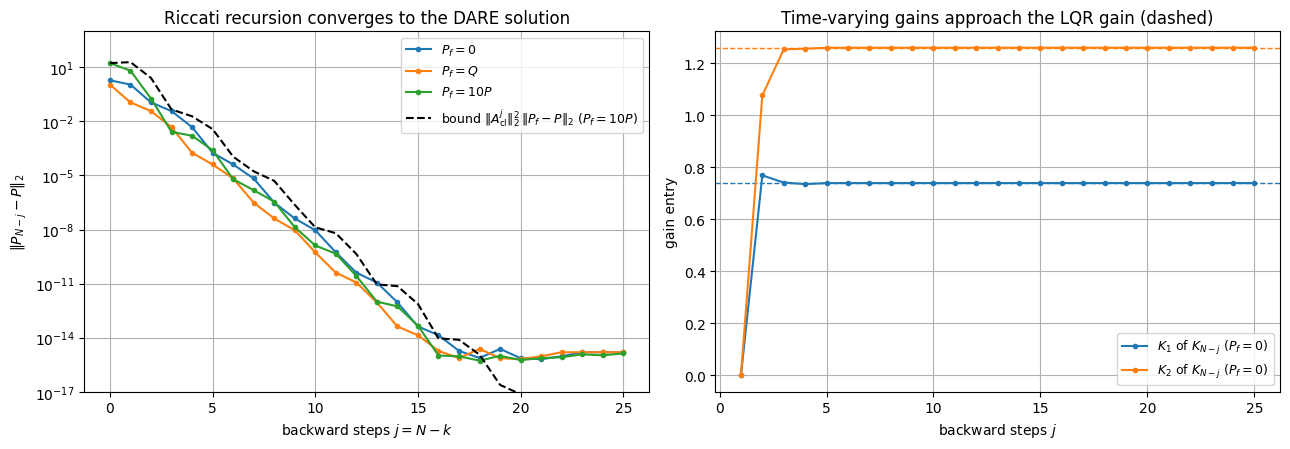

In [3]:
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.5],
              [1.0]])
Q = np.diag([1.0, 0.2])
R = np.array([[0.2]])

K, P, eig_cl = dlqr(A, B, Q, R)
Acl = A - B @ K
rho = np.max(np.abs(eig_cl))


def riccati_step(P_next):
    """One backward DP step of the unconstrained LQ problem: returns (P_k, K_k)."""
    H = R + B.T @ P_next @ B
    K_k = np.linalg.solve(H, B.T @ P_next @ A)
    return Q + A.T @ P_next @ A - A.T @ P_next @ B @ K_k, K_k


n_back = 25
runs = {}
for label, Pf in [("$P_f=0$", np.zeros((2, 2))), ("$P_f=Q$", Q.copy()), ("$P_f=10P$", 10 * P)]:
    Pj, errs, gains = Pf.copy(), [np.linalg.norm(Pf - P, 2)], []
    for j in range(n_back):
        Pj, Kj = riccati_step(Pj)
        errs.append(np.linalg.norm(Pj - P, 2))
        gains.append(Kj.ravel())
    runs[label] = (np.array(errs), np.array(gains))

print("P from dlqr:\n", P)
print("K from dlqr:", K.ravel())
print(f"rho(A_cl) = {rho:.4f}   rho^2 = {rho ** 2:.4f}")
for label, (errs, gains) in runs.items():
    print(f"{label:>10}: ||P_(N-25) - P|| = {errs[-1]:.1e}   max|K_(N-25) - K| = "
          f"{np.max(np.abs(gains[-1] - K.ravel())):.1e}   mean rate per step, j=2..12: {(errs[12] / errs[2]) ** 0.1:.3f}")

# Sandwich check for P_f = 10P: 0 <= E_j <= (A_cl^T)^j E_0 A_cl^j in the PSD order.
E0, Pj, lo, hi = 9 * P, 10 * P, [], []
for j in range(1, 11):
    Pj, _ = riccati_step(Pj)
    Aj = np.linalg.matrix_power(Acl, j)
    lo.append(np.linalg.eigvalsh(Pj - P).min() / np.linalg.norm(Pj - P, 2))
    hi.append(np.linalg.eigvalsh(Aj.T @ E0 @ Aj - (Pj - P)).min() / np.linalg.norm(Pj - P, 2))
print(f"j=1..10: min eig(E_j)/||E_j|| = {min(lo):.2e},  min eig(bound - E_j)/||E_j|| = {min(hi):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
jj = np.arange(n_back + 1)
for label, (errs, _) in runs.items():
    ax.semilogy(jj, np.maximum(errs, 1e-17), "o-", ms=3, label=label)
bound = [np.linalg.norm(np.linalg.matrix_power(Acl, j), 2) ** 2 * np.linalg.norm(E0, 2) for j in jj]
ax.semilogy(jj, bound, "k--", label=r"bound $\|A_{\rm cl}^j\|_2^2\,\|P_f-P\|_2$ ($P_f=10P$)")
ax.set_ylim(1e-17, 1e3)
ax.set_xlabel("backward steps $j=N-k$")
ax.set_ylabel(r"$\|P_{N-j}-P\|_2$")
ax.set_title("Riccati recursion converges to the DARE solution")
ax.legend(fontsize=9)
ax = axes[1]
gains0 = runs["$P_f=0$"][1]
for i, name in enumerate(["$K_1$", "$K_2$"]):
    ax.plot(np.arange(1, n_back + 1), gains0[:, i], "o-", ms=3, label=f"{name} of $K_{{N-j}}$ ($P_f=0$)")
    ax.axhline(K.ravel()[i], color=f"C{i}", ls="--", lw=1)
ax.set_xlabel("backward steps $j$")
ax.set_ylabel("gain entry")
ax.set_title("Time-varying gains approach the LQR gain (dashed)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Reading the result.** All three recursions reach the `dlqr` solution to machine precision (about
$10^{-15}$ after 25 steps), gains included. Over $j=2,\ldots,12$ the error shrinks by a factor
between 0.104 and 0.114 per step, close to $\rho(A_{\mathrm{cl}})^2=0.109$; single steps oscillate
because $A_{\mathrm{cl}}$ has complex eigenvalues. Both sandwich inequalities hold to rounding error.
Note what $P_f=P$ means: the recursion starts at its limit, so an unconstrained MPC with terminal
weight $P$ reproduces the LQR law at every horizon.

<a id="part-3"></a>
# Part III — Infinite horizon: the Bellman operator

## III.1 The Bellman equation

Let $f$ and $q$ be stationary, let $\mathcal U(x)\neq\emptyset$ be the admissible inputs at $x$, and
discount by $\gamma\in[0,1)$. A stationary policy $\mu$ costs
$J_\mu(x)=\sum_{k\ge0}\gamma^kq(x_k,\mu(x_k))$, and $J^\star$ is the infimum over input sequences.
The **Bellman operators** are

$$
(TJ)(x)=\min_{u\in\mathcal U(x)}\Big\{q(x,u)+\gamma J\big(f(x,u)\big)\Big\},
\qquad
(T_\mu J)(x)=q\big(x,\mu(x)\big)+\gamma J\big(f(x,\mu(x))\big).
$$

Part I is $J_k=TJ_{k+1}$ with $\gamma=1$, so **value iteration** $J_{k+1}=TJ_k$ is DP with an ever
longer horizon, and $J^\star$ satisfies the **Bellman equation** $J^\star=TJ^\star$.

**Assumptions.** (A1) bounded costs, $|q(x,u)|\le M$; (A2) $\gamma<1$; (A3) the minimum in $T$ is
attained (finite input sets). We work in the space $\mathcal B$ of bounded functions with
$\|J\|_\infty=\sup_x|J(x)|$.

## III.2 $T$ is a $\gamma$-contraction

Two properties suffice: **monotonicity** ($J\le J'$ implies $TJ\le TJ'$) and the **constant shift**
$T(J+c\mathbf 1)=TJ+\gamma c\mathbf 1$.

> **Theorem.** Under (A1)–(A3), $T$ maps $\mathcal B$ into itself and
> $\|TJ-TJ'\|_\infty\le\gamma\|J-J'\|_\infty$. The same holds for $T_\mu$.

*Proof.* $|(TJ)(x)|\le M+\gamma\|J\|_\infty$. With $c=\|J-J'\|_\infty$ we have
$J'-c\mathbf 1\le J\le J'+c\mathbf 1$, and monotonicity and the shift give
$TJ'-\gamma c\mathbf 1\le TJ\le TJ'+\gamma c\mathbf 1$. $\square$

Boundedness makes $J-J'$ meaningful (with $+\infty$ constraint costs it is not), and $\gamma<1$ *is*
the contraction factor: for $\gamma=1$ the proof only gives non-expansiveness, and fixed points can be
non-unique (zero cost and $f(x,u)=x$ make every constant a fixed point).

## III.3 Consequences

By Banach's fixed-point theorem:

1. $J^\star$ is the unique fixed point of $T$ in $\mathcal B$ (it solves the Bellman equation and is
   bounded by $M/(1-\gamma)$).
2. Value iteration converges from any bounded $J_0$, with
   $\|J_k-J^\star\|_\infty\le\gamma^k\|J_0-J^\star\|_\infty$, and
   $\|J_k-J^\star\|_\infty\le\frac{\gamma}{1-\gamma}\|J_k-J_{k-1}\|_\infty$ is a stopping rule.
3. $J_\mu$ is the unique fixed point of $T_\mu$. A greedy policy $\mu^\star$ satisfies
   $T_{\mu^\star}J^\star=TJ^\star=J^\star$, hence $J_{\mu^\star}=J^\star$: an optimal stationary
   policy is read off $J^\star$ by a one-step minimization.
4. If $\tilde\mu$ is greedy for an approximation $\tilde J$, then
   $\|J_{\tilde\mu}-J^\star\|_\infty\le\frac{2\gamma}{1-\gamma}\|\tilde J-J^\star\|_\infty$. Write
   $J_{\tilde\mu}-J^\star=(T_{\tilde\mu}J_{\tilde\mu}-T_{\tilde\mu}\tilde J)+(T\tilde J-TJ^\star)$ and
   use both contractions. Good approximate costs-to-go (terminal costs, learned values) give good
   policies.

## III.4 A finite test problem: the double integrator on a lattice

Choose $h$ with $1/h$ an integer and keep only

$$
v\in h\mathbb Z,\qquad p+\tfrac v2\in h\mathbb Z,\qquad u\in h\mathbb Z,
\qquad |p|\le4,\ |v|\le3,\ |u|\le1,
$$

with the bounds of notebook 02. Since $x^+=(p+v+u/2,\ v+u)$, we get $v^+\in h\mathbb Z$ and
$p^++v^+/2=(p+v/2)+v+u\in h\mathbb Z$: **the lattice is mapped into itself exactly.** Every lattice
trajectory is a true trajectory of the double integrator, so lattice results are exact statements
about a restricted problem. Here $h=0.5$, $q$ is the LQ cost of Part II and $\gamma=0.95$. To satisfy
(A1), leaving the box costs $c_{\mathrm{crash}}=100$ and ends in an absorbing, cost-free crash state,
the usual RL encoding of a constraint.

## III.5 Value iteration

The code builds the lattice (reused in Parts IV–VI), checks it, and runs value iteration from three
initial guesses.

lattice h=0.5: 215 states, 5 inputs;  max |S[succ] - (Ax+Bu)| = 0.0;  -1 exactly outside: True
J* certified after 11 iterations from J_0 = 0;  states with tied optimal actions: 0
viable states: 171 of 215;  max J* on viable = 47.06;  min J* on non-viable = 101.85
optimal policy keeps every viable state viable: True
        J_0 = 0: ||J_0 - J*|| =   117.8   max_(k>=1) err/bound = 0.895362   k=50: err 0.00e+00, bound 9.06e+00   greedy optimal from k = 6   exact from k = 10
     J_0 = 2000: ||J_0 - J*|| =  2000.0   max_(k>=1) err/bound = 1.000000   k=50: err 1.54e+02, bound 1.54e+02   greedy optimal from k = 6   exact from k = None
J_0 ~ U[0,2000]: ||J_0 - J*|| =  1987.1   max_(k>=1) err/bound = 0.552517   k=50: err 6.08e+01, bound 1.53e+02   greedy optimal from k = 8   exact from k = None


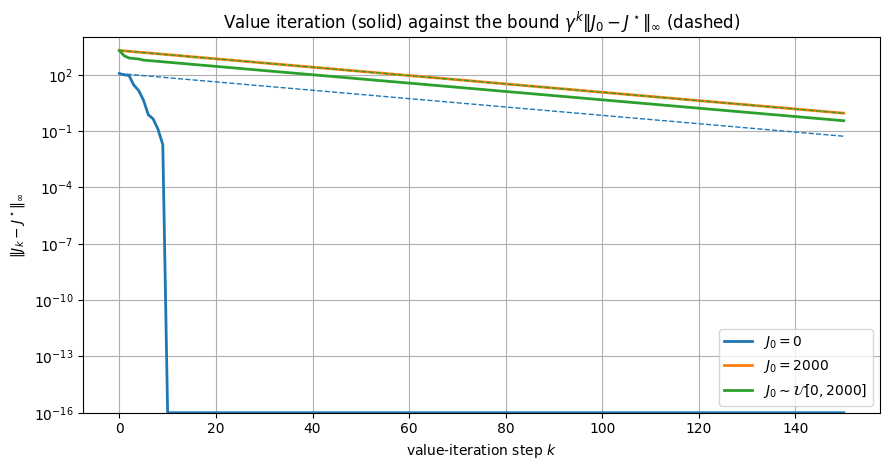

In [4]:
def build_lattice(h, p_max=4.0, v_max=3.0, u_max=1.0):
    """Double integrator restricted to the lattice {v in hZ, p + v/2 in hZ} with inputs u in hZ.

    Returns states S (n x 2), inputs U (m,), successor indices succ (n x m, -1 when the
    successor leaves |p| <= p_max, |v| <= v_max) and stage costs qsa = x'Qx + u'Ru (n x m).
    """
    Pm, Vm, Am = round(2 * p_max / h), round(v_max / h), round(u_max / h)
    I0 = (Pm + Vm) // 2 + 1
    ij = np.array([(i, j) for j in range(-Vm, Vm + 1) for i in range(-I0, I0 + 1)
                   if abs(2 * i - j) <= Pm])            # p + v/2 = i h, v = j h
    index = -np.ones((2 * I0 + 1, 2 * Vm + 1), dtype=int)
    index[ij[:, 0] + I0, ij[:, 1] + Vm] = np.arange(len(ij))
    a = np.arange(-Am, Am + 1)                           # u = a h
    i_next = ij[:, [0]] + ij[:, [1]] + a                 # (p + v/2)+ = (p + v/2) + v + u
    j_next = ij[:, [1]] + a                              # v+ = v + u
    inside = (np.abs(j_next) <= Vm) & (np.abs(2 * i_next - j_next) <= Pm)
    succ = np.where(inside, index[np.clip(i_next + I0, 0, 2 * I0), np.clip(j_next + Vm, 0, 2 * Vm)], -1)
    S = np.c_[(2 * ij[:, 0] - ij[:, 1]) * h / 2, ij[:, 1] * h]
    U = a * h
    qsa = np.einsum("ni,ij,nj->n", S, Q, S)[:, None] + R[0, 0] * U[None, :] ** 2
    return S, U, succ, qsa


h3, gamma, c_crash = 0.5, 0.95, 100.0
S3, U3, succ3, q3 = build_lattice(h3)
n3, m3 = q3.shape

# Exactness check: the lattice successor equals A x + B u, and -1 exactly when A x + B u leaves the box.
X_next = S3 @ A.T + U3[:, None, None] * B.ravel()        # (m, n, 2)
X_next = np.transpose(X_next, (1, 0, 2))
inside = (np.abs(X_next[..., 0]) <= 4) & (np.abs(X_next[..., 1]) <= 3)
print(f"lattice h={h3}: {n3} states, {m3} inputs;  max |S[succ] - (Ax+Bu)| = "
      f"{np.abs(S3[succ3[inside]] - X_next[inside]).max()};  -1 exactly outside: {np.array_equal(inside, succ3 >= 0)}")

crash = n3                                               # index of the absorbing crash state
succ_c = np.vstack([np.where(succ3 >= 0, succ3, crash), np.full((1, m3), crash)])
cost_c = np.vstack([q3 + c_crash * (succ3 < 0), np.zeros((1, m3))])


def bellman(J):
    """Discounted Bellman operator of the crash problem: returns (TJ, greedy action indices)."""
    Qsa = cost_c + gamma * J[succ_c]
    return Qsa.min(axis=1), Qsa.argmin(axis=1)


J = np.zeros(n3 + 1)                                      # J* with the a posteriori stopping rule
for k in range(1, 5000):
    J_new, _ = bellman(J)
    if gamma / (1 - gamma) * np.max(np.abs(J_new - J)) < 1e-12:
        break
    J = J_new
J_star3 = J_new
mu_star3 = bellman(J_star3)[1]
Q_star3 = cost_c + gamma * J_star3[succ_c]
opt_action3 = Q_star3 <= J_star3[:, None] + 1e-9         # optimal actions (no ties occur here)
print(f"J* certified after {k} iterations from J_0 = 0;  states with tied optimal actions: "
      f"{int((opt_action3[:n3].sum(axis=1) > 1).sum())}")

# Viable states: those from which some input sequence never leaves the box (a Boolean DP).
viable3 = np.ones(n3, bool)
while True:
    nxt = viable3 & np.any((succ3 >= 0) & viable3[np.maximum(succ3, 0)], axis=1)
    if np.array_equal(nxt, viable3):
        break
    viable3 = nxt
s_next = succ3[np.arange(n3), mu_star3[:n3]]
print(f"viable states: {viable3.sum()} of {n3};  max J* on viable = {J_star3[:n3][viable3].max():.2f};  "
      f"min J* on non-viable = {J_star3[:n3][~viable3].min():.2f}")
print("optimal policy keeps every viable state viable:",
      bool(np.all(s_next[viable3] >= 0) and np.all(viable3[s_next[viable3]])))

rng = np.random.default_rng(0)
inits = [("J_0 = 0", "$J_0=0$", np.zeros(n3 + 1)),
         ("J_0 = 2000", "$J_0=2000$", np.full(n3 + 1, 2000.0)),
         ("J_0 ~ U[0,2000]", r"$J_0\sim\mathcal{U}[0,2000]$", rng.uniform(0, 2000, n3 + 1))]
K_vi = 150
fig, ax = plt.subplots(figsize=(9, 4.8))
for c, (name, label, J0) in enumerate(inits):
    J, errs, k_pol = J0.copy(), [np.max(np.abs(J0 - J_star3))], None
    for k in range(1, K_vi + 1):
        J, mu = bellman(J)
        errs.append(np.max(np.abs(J - J_star3)))
        if k_pol is None and opt_action3[np.arange(n3 + 1), mu].all():
            k_pol = k
    errs = np.array(errs)
    bound = errs[0] * gamma ** np.arange(K_vi + 1)
    zero = np.flatnonzero(errs == 0)
    print(f"{name:>15}: ||J_0 - J*|| = {errs[0]:7.1f}   max_(k>=1) err/bound = {np.max(errs[1:] / bound[1:]):.6f}   "
          f"k=50: err {errs[50]:.2e}, bound {bound[50]:.2e}   greedy optimal from k = {k_pol}   "
          f"exact from k = {zero[0] if zero.size else None}")
    ax.semilogy(np.arange(K_vi + 1), np.maximum(errs, 1e-16), color=f"C{c}", lw=2, label=label)
    ax.semilogy(np.arange(K_vi + 1), bound, color=f"C{c}", ls="--", lw=1)
ax.set_ylim(1e-16, 1e4)
ax.set_xlabel("value-iteration step $k$")
ax.set_ylabel(r"$\|J_k-J^\star\|_\infty$")
ax.set_title(r"Value iteration (solid) against the bound $\gamma^k\|J_0-J^\star\|_\infty$ (dashed)")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the result.** The lattice is exact (215 states, 5 inputs). Of its states, 171 are
**viable**: some input sequence keeps them in the box forever. The optimal policy never crashes from
them ($J^\star\le47.06$ there, $J^\star\ge101.85$ elsewhere), so the penalty does not alter the
constrained behavior.

- **The bound is tight.** From $J_0=2000$ the error equals $\gamma^k\|J_0-J^\star\|_\infty$: at the
  absorbing, cost-free origin, $T$ acts as $J\mapsto\gamma J$.
- **A good start helps.** From $J_0=0$ the iteration is exact after 10 steps, because every optimal
  trajectory reaches an absorbing state within 10 steps. The random start lies in between.
- **Policies converge before values.** The greedy policy is optimal after 6 steps from both constant
  starts (8 from the random one), because a constant offset in $J$ does not change the minimizer.

## III.6 Policy iteration

From an initial policy $\mu_0$, alternate **evaluation**, solving $(I-\gamma P_{\mu_k})J=q_{\mu_k}$
for $J_{\mu_k}$ ($P_\mu$ is the 0/1 closed-loop transition matrix, and the system is invertible
because $\|\gamma P_\mu\|_\infty=\gamma<1$), and **improvement**,
$\mu_{k+1}(x)\in\arg\min_u\{q(x,u)+\gamma J_{\mu_k}(f(x,u))\}$, keeping $\mu_k(x)$ on ties.

Since $T_{\mu_{k+1}}J_{\mu_k}=TJ_{\mu_k}\le J_{\mu_k}$, applying the monotone $T_{\mu_{k+1}}$
repeatedly gives $J_{\mu_{k+1}}\le J_{\mu_k}$, strictly at some state whenever an action changes. No
policy can repeat and there are finitely many, so the algorithm stops; at that point
$TJ_{\mu_k}=J_{\mu_k}$, that is, $J_{\mu_k}=J^\star$.

In [5]:
def evaluate(mu):
    """Policy evaluation: solve (I - gamma P_mu) J = q_mu exactly."""
    rows = np.arange(n3 + 1)
    P_mu = np.zeros((n3 + 1, n3 + 1))
    P_mu[rows, succ_c[rows, mu]] = 1.0
    return np.linalg.solve(np.eye(n3 + 1) - gamma * P_mu, cost_c[rows, mu])


mu = np.full(n3 + 1, m3 // 2)                            # mu_0: u = 0 everywhere (coast)
print(" k   ||J_mu_k - J*||_inf   actions changed by the improvement step")
for k in range(50):
    J_mu = evaluate(mu)
    Qsa = cost_c + gamma * J_mu[succ_c]
    keep = Qsa[np.arange(n3 + 1), mu] <= Qsa.min(axis=1) + 1e-10
    mu_new = np.where(keep, mu, Qsa.argmin(axis=1))
    changed = int(np.sum(mu_new != mu))
    print(f"{k:2d}   {np.max(np.abs(J_mu - J_star3)):18.3e}   {changed:6d}")
    if changed == 0:
        break
    mu = mu_new
print(f"deterministic stationary policies on the {n3} lattice states: {m3}^{n3} = 10^{n3 * np.log10(m3):.1f}")

 k   ||J_mu_k - J*||_inf   actions changed by the improvement step


 0            2.867e+02      140
 1            9.763e+01      120
 2            9.170e+01       46
 3            7.480e+01        6


 4            1.421e-14        0
deterministic stationary policies on the 215 lattice states: 5^215 = 10^150.3


From "coast" ($u=0$ everywhere) the four improvement steps change 140, 120, 46 and 6 actions, and the
fifth evaluation equals $J^\star$ to rounding error, in a policy space of $5^{215}\approx10^{150}$
elements. Each iteration costs a linear solve instead of a sweep, but very few are needed.

<a id="part-4"></a>
# Part IV — The constrained double integrator

## IV.1 Hard constraints without discount

MPC problems are undiscounted with hard constraints, so the contraction argument fails twice. Take the
lattice with $h=0.25$, no crash state (inputs that leave the box are inadmissible) and $\gamma=1$,
and iterate $J_{k+1}=TJ_k$ from $J_0=0$.

- **Monotonicity replaces contraction.** Since $q\ge0$, $J_1\ge J_0$, and by induction
  $J_{k+1}\ge J_k$: $J_k$ is the optimal $k$-step cost, a lower bound on $J^\star$.
- **Finite convergence.** Off the origin, $q\ge x^\top Qx\ge c_{\min}>0$ on the lattice, so a
  finite-cost trajectory must reach the origin, and a $k$-step path that has not reached it costs at
  least $kc_{\min}$. Hence $J_k(x)=J^\star(x)$ once $k>J^\star(x)/c_{\min}$.

## IV.2 The cost-to-go landscape

lattice h=0.25: 813 states, 9 inputs
exact fixed point J_k = J_(k+1) reached at k = 10;  c_min = 0.0281,  max finite J* = 57.12  (worst-case bound J*/c_min = 2031 iterations)
finite-cost states per iteration |dom J_k|: [813, 703, 661, 655, 655, 655, 655, 655, 655, 655, 655]


min over finite states of J* - x'Px = 0
lattice states in O_inf: 117;  relative gap (J* - x'Px)/x'Px there: median 0.0060, mean 0.0192, max 0.1670


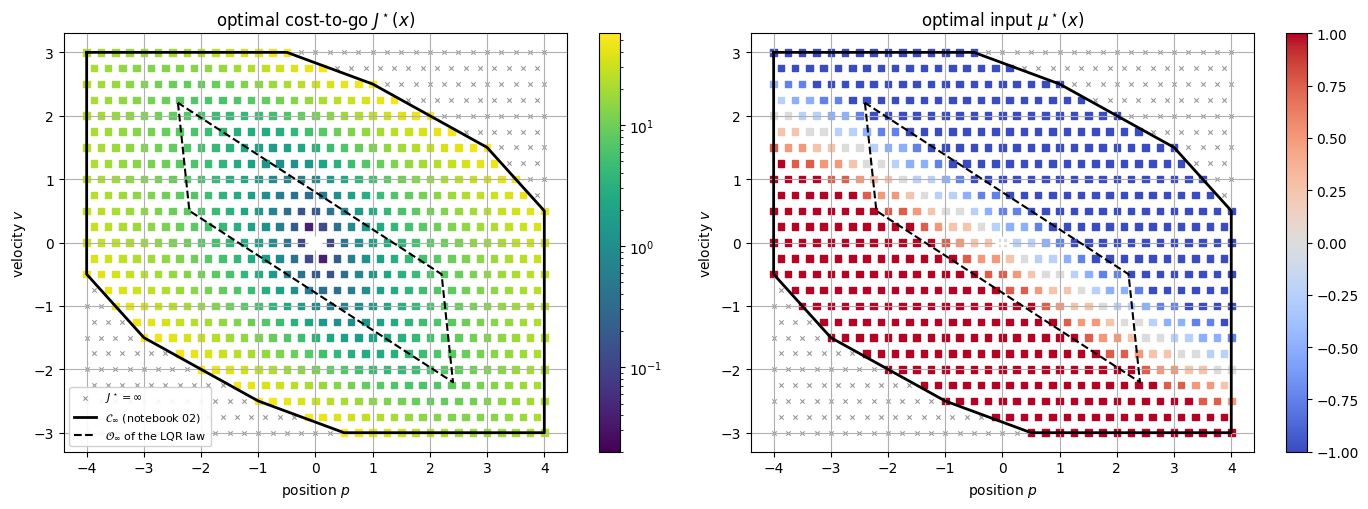

In [6]:
h4 = 0.25
S4, U4, succ4, q4 = build_lattice(h4)
n4, m4 = q4.shape
q4_hard = np.where(succ4 >= 0, q4, np.inf)               # leaving the box is not admissible


def bellman_hard(J):
    """Undiscounted Bellman operator with hard constraints: returns (TJ, greedy action indices)."""
    Qsa = q4_hard + J[np.maximum(succ4, 0)]
    return Qsa.min(axis=1), Qsa.argmin(axis=1)


J_iter = [np.zeros(n4)]                                   # J_0 = 0
while True:
    J_new, _ = bellman_hard(J_iter[-1])
    if np.array_equal(J_new, J_iter[-1]):                 # exact fixed point (inf == inf counts)
        break
    J_iter.append(J_new)
J_star4 = J_iter[-1]
mu_star4 = U4[bellman_hard(J_star4)[1]]
fin4 = np.isfinite(J_star4)
xQx = np.einsum("ni,ij,nj->n", S4, Q, S4)
print(f"lattice h={h4}: {n4} states, {m4} inputs")
print(f"exact fixed point J_k = J_(k+1) reached at k = {len(J_iter) - 1};  "
      f"c_min = {xQx[xQx > 0].min():.4f},  max finite J* = {J_star4[fin4].max():.2f}  "
      f"(worst-case bound J*/c_min = {J_star4[fin4].max() / xQx[xQx > 0].min():.0f} iterations)")
print("finite-cost states per iteration |dom J_k|:", [int(np.isfinite(Jk).sum()) for Jk in J_iter])

X_box = HPolytope.box([-4.0, -3.0], [4.0, 3.0])
C_inf, C_hist = maximal_control_invariant(A, B, X_box, -1.0, 1.0)
O_inf, _ = maximal_invariant(Acl, closed_loop_admissible_set_scalar_input(X_box, K, -1.0, 1.0))


def inside(poly, pts, tol=1e-9):
    return np.all(poly.H @ pts.T <= poly.h[:, None] + tol, axis=0)


xPx4 = np.einsum("ni,ij,nj->n", S4, P, S4)
in_O = inside(O_inf, S4)
gap = (J_star4[in_O & (xPx4 > 0)] - xPx4[in_O & (xPx4 > 0)]) / xPx4[in_O & (xPx4 > 0)]
print(f"min over finite states of J* - x'Px = {np.min(J_star4[fin4] - xPx4[fin4]):.3g}")
print(f"lattice states in O_inf: {in_O.sum()};  relative gap (J* - x'Px)/x'Px there: "
      f"median {np.median(gap):.4f}, mean {gap.mean():.4f}, max {gap.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
panels = [(J_star4, r"optimal cost-to-go $J^\star(x)$", dict(cmap="viridis", norm=LogNorm(0.02, J_star4[fin4].max()))),
          (mu_star4, r"optimal input $\mu^\star(x)$", dict(cmap="coolwarm", vmin=-1, vmax=1))]
for ax, (vals, title, style) in zip(axes, panels):
    sc = ax.scatter(S4[fin4, 0], S4[fin4, 1], c=vals[fin4], marker="s", s=22, **style)
    ax.scatter(S4[~fin4, 0], S4[~fin4, 1], marker="x", s=10, color="0.6", lw=0.8, label=r"$J^\star=\infty$")
    plot_polytope(ax, C_inf, color="k", lw=2, label=r"$\mathcal{C}_\infty$ (notebook 02)")
    plot_polytope(ax, O_inf, color="k", lw=1.5, ls="--", label=r"$\mathcal{O}_\infty$ of the LQR law")
    ax.plot(0, 0, "w+", ms=10, mew=2)
    ax.set_xlabel("position $p$")
    ax.set_ylabel("velocity $v$")
    ax.set_title(title)
    fig.colorbar(sc, ax=ax)
axes[0].legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

**Reading the result.** The fixed point is reached after 10 iterations, far below the bound
$J^\star/c_{\min}\approx2031$, and the finite-cost set shrinks from 813 to 703, 661 and 655 states.
$J^\star$ is largest at large $|p|$ and along the slanted edges of the finite-cost set, where the state
moves away from the origin almost as fast as can still be braked. The policy is **bang-bang** except
near the origin. Everywhere $J^\star\ge x^\top Px$, the unconstrained optimum. Inside
$\mathcal O_\infty$ (117 states), where LQR solves the continuous constrained problem, the lattice
value exceeds $x^\top Px$ by a median of 0.6% (maximum 16.7%): the price of rounding the inputs.

## IV.3 The domain of $J^\star$ and the sets of notebook 02

Whatever finite values $q$ takes on $\mathcal X\times\mathcal U$, the Bellman step acts on domains as
$\operatorname{dom}(TJ)=\mathcal X\cap\operatorname{Pre}(\operatorname{dom}J)$. From $J_0=0$ the
domains are therefore the outer iterates $\mathcal C_{k+1}=\mathcal X\cap\operatorname{Pre}(\mathcal C_k)$,
$\mathcal C_0=\mathcal X$, that notebook 02 uses to compute the maximal control-invariant set
$\mathcal C_\infty$. From $J_0=\bar V_f$ they are the controllable sets
$\mathcal K_k(\mathcal X_f)$ (Part V). Lattice inputs form a subset of $[-1,1]$, so each lattice
domain lies inside the corresponding polytope.

 k   lattice states in C_k (polytope)   |dom J_k| (value iteration)
 0                              813                           813
 1                              703                           703
 2                              661                           661
 3                              655                           655
 4                              655                           655
every finite-cost lattice state lies in C_inf: True
lattice states in C_inf with infinite cost: 0


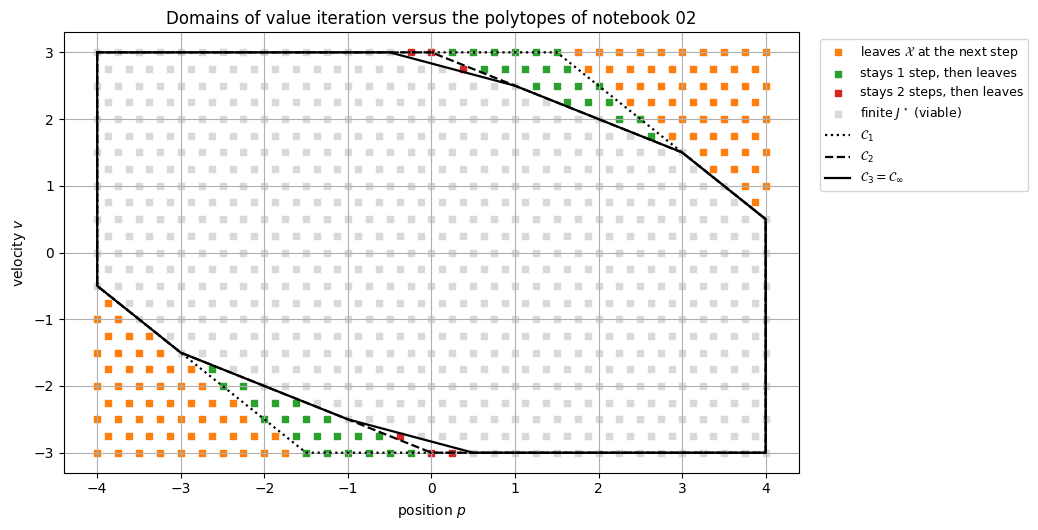

In [7]:
survive = np.array([sum(np.isfinite(Jk[i]) for Jk in J_iter) - 1 for i in range(n4)])   # steps kept in X
survive[fin4] = len(J_iter)                                                               # viable: forever
print(" k   lattice states in C_k (polytope)   |dom J_k| (value iteration)")
for k, Ck in enumerate(C_hist):
    Jk = J_iter[min(k, len(J_iter) - 1)]
    print(f"{k:2d}   {inside(Ck, S4).sum():30d}   {int(np.isfinite(Jk).sum()):27d}")
print("every finite-cost lattice state lies in C_inf:", bool(np.all(inside(C_inf, S4)[fin4])))
print("lattice states in C_inf with infinite cost:", int(np.sum(inside(C_inf, S4) & ~fin4)))

fig, ax = plt.subplots(figsize=(10.5, 5.4))
labels = {0: "leaves $\\mathcal{X}$ at the next step", 1: "stays 1 step, then leaves",
          2: "stays 2 steps, then leaves"}
for s, lab in labels.items():
    sel = survive == s
    ax.scatter(S4[sel, 0], S4[sel, 1], marker="s", s=22, color=f"C{s + 1}", label=lab)
ax.scatter(S4[fin4, 0], S4[fin4, 1], marker="s", s=22, color="0.85", label=r"finite $J^\star$ (viable)")
for k, ls in zip([1, 2, len(C_hist) - 2], [":", "--", "-"]):
    plot_polytope(ax, C_hist[k], color="k", ls=ls, lw=1.6,
                  label=rf"$\mathcal{{C}}_{{{k}}}$" + (r"$=\mathcal{C}_\infty$" if k == len(C_hist) - 2 else ""))
ax.set_xlabel("position $p$")
ax.set_ylabel("velocity $v$")
ax.set_title("Domains of value iteration versus the polytopes of notebook 02")
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.tight_layout()
plt.show()

The counts agree at every iteration (813, 703, 661, 655, 655). With the inclusion, this means the sets
agree **state for state**, and the finite-cost states are exactly the lattice points of
$\mathcal C_\infty$: the set recursions of notebook 02 are the $\{0,\infty\}$ shadow of value
iteration. The colored states satisfy the constraints now but are **doomed** to leave $\mathcal X$
within three steps, which DP reports as infinite cost. Since lattice costs upper-bound continuous
ones, the continuous $J^\star$ is finite at every lattice point of $\mathcal C_\infty$.

## IV.4 The curse of dimensionality

A table with $n_g$ points per axis in $n$ dimensions holds $n_g^{\,n}$ values, and each sweep
evaluates all of them against every input; $m$ inputs at $n_u$ levels give $n_u^{\,m}$ candidates.
Bellman called this growth the *curse of dimensionality*.

 n   points at n_g=30   memory of one float64 table
 2           9.00e+02          7.2e-06 GB
 4           8.10e+05          0.00648 GB
 6           7.29e+08             5.83 GB
 8           6.56e+11         5.25e+03 GB
12           5.31e+17         4.25e+09 GB


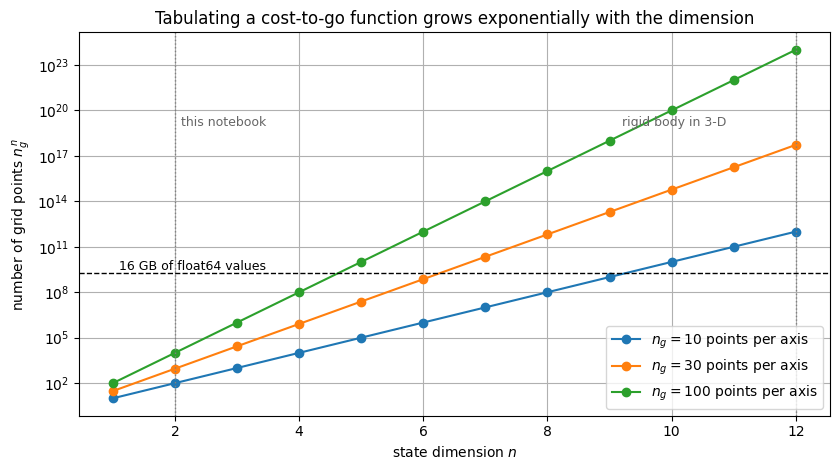

In [8]:
dims = np.arange(1, 13)
print(" n   points at n_g=30   memory of one float64 table")
for n_dim in [2, 4, 6, 8, 12]:
    pts = 30.0 ** n_dim
    print(f"{n_dim:2d}   {pts:16.2e}   {pts * 8 / 1e9:14.3g} GB")

fig, ax = plt.subplots(figsize=(8.5, 4.8))
for n_g in [10, 30, 100]:
    ax.semilogy(dims, float(n_g) ** dims, "o-", label=f"$n_g={n_g}$ points per axis")
ax.axhline(2e9, color="k", ls="--", lw=1)
ax.text(1.1, 3e9, "16 GB of float64 values", fontsize=9)
ax.axvline(2, color="0.5", ls=":", lw=1)
ax.text(2.1, 1e19, "this notebook", fontsize=9, color="0.4")
ax.axvline(12, color="0.5", ls=":", lw=1)
ax.text(9.2, 1e19, "rigid body in 3-D", fontsize=9, color="0.4")
ax.set_xlabel("state dimension $n$")
ax.set_ylabel("number of grid points $n_g^{\\,n}$")
ax.set_title("Tabulating a cost-to-go function grows exponentially with the dimension")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

At about 30 points per axis (25 to 33 here), $n=6$ needs $7.29\times10^{8}$ values (5.83 GB per
table), and the 12 states of a rigid body in space need $5.31\times10^{17}$. Two escapes structure
the rest of the notebook: **do not tabulate**, but optimize only at the current state over a finite
horizon with an approximate tail (MPC, Part V); or **do not grid**, but fit a parametric approximator
to samples (Part VI).

<a id="part-5"></a>
# Part V — Where MPC and LMPC fit

## V.1 MPC is truncated DP

The MPC problem at state $x$ is the finite-horizon problem of Part I, so by I.3

$$
J_N(x)=\big(T^N\bar V_f\big)(x),
\qquad
\kappa_N(x)\in\arg\min_{u}\Big\{\bar q(x,u)+\big(T^{N-1}\bar V_f\big)\big(f(x,u)\big)\Big\},
$$

with $T$ the undiscounted constrained operator of Part IV. **MPC is the greedy policy with respect
to $T^{N-1}\bar V_f$**, evaluated only at the current state by solving an optimization over $N$
inputs. Its feasible set is $\operatorname{dom}T^N\bar V_f=\mathcal K_N(\mathcal X_f)$.

## V.2 What a good terminal cost buys

1. **An exact tail gives exact MPC.** If $V_f=J^\star$ on $\mathcal X_f$, then $\bar V_f\ge J^\star$
   and monotonicity gives $T^N\bar V_f\ge T^NJ^\star=J^\star$, with equality wherever an optimal
   trajectory enters $\mathcal X_f$ within $N$ steps: the horizon only has to reach $\mathcal X_f$.
2. **Terminal decrease gives a monotone value and stability.** The terminal assumptions of
   notebook 03 (for every $x\in\mathcal X_f$, an admissible $u$ with $f(x,u)\in\mathcal X_f$ and
   $V_f(f(x,u))-V_f(x)\le-q(x,u)$) say exactly that $\bar V_f\ge T\bar V_f$. Applying $T^N$ gives
   $J_N\ge J_{N+1}$, and with $x^+=f(x,\kappa_N(x))$,
   $$J_N(x)=q\big(x,\kappa_N(x)\big)+J_{N-1}(x^+)\ \ge\ q\big(x,\kappa_N(x)\big)+J_N(x^+).$$
   So $J_N$ is a Lyapunov function, $x^+\in\operatorname{dom}J_{N-1}\subseteq\operatorname{dom}J_N$
   gives recursive feasibility, and the closed-loop cost is at most $J_N(x_0)$.
3. **Without terminal ingredients the tail is underestimated.** With $V_f=0$ and
   $\mathcal X_f=\mathcal X$, $T^N0\le J^\star$, the feasible set $\mathcal C_N$ contains doomed states
   for small $N$, and fact 2 is unavailable.

With discounting the effect is quantitative: by III.3, the greedy policy of $T^{N-1}V_f$ is within
$\tfrac{2\gamma^N}{1-\gamma}\|V_f-J^\star\|_\infty$ of optimal.

## V.3 Terminal ingredients compared on the lattice

On the lattice the MPC law is a table, so the receding-horizon closed loop can be run from every
feasible state. Three designs: **A**, $V_f=0$ and $\mathcal X_f=\mathcal X$; **B**,
$V_f=x^\top Px$ on $\mathcal X_f=\mathcal O_\infty$; **C**, $V_f=J^\star$ on the same
$\mathcal X_f$. A closed loop **fails** if the MPC problem becomes infeasible or the origin is not
reached within 80 steps.

design  N  feasible  doomed  failed  optimal  mean_subopt_pct  max_subopt_pct
     A  1       703      48     702        1              NaN             NaN
     A  2       661       6       6       41           11.169         146.589
     A  3       655       0       0      509            0.413           8.837
     A  4       655       0       0      637            0.002           0.160
     A  5       655       0       0      655            0.000           0.000
     A  8       655       0       0      655            0.000           0.000
     A 12       655       0       0      655            0.000           0.000
     B  1       313       0       0      241            0.328           2.568
     B  2       449       0       0      425            0.048           1.424
     B  3       561       0       0      561            0.000           0.000
     B  4       629       0       0      629            0.000           0.000
     B  5       655       0       0      655            0.000   

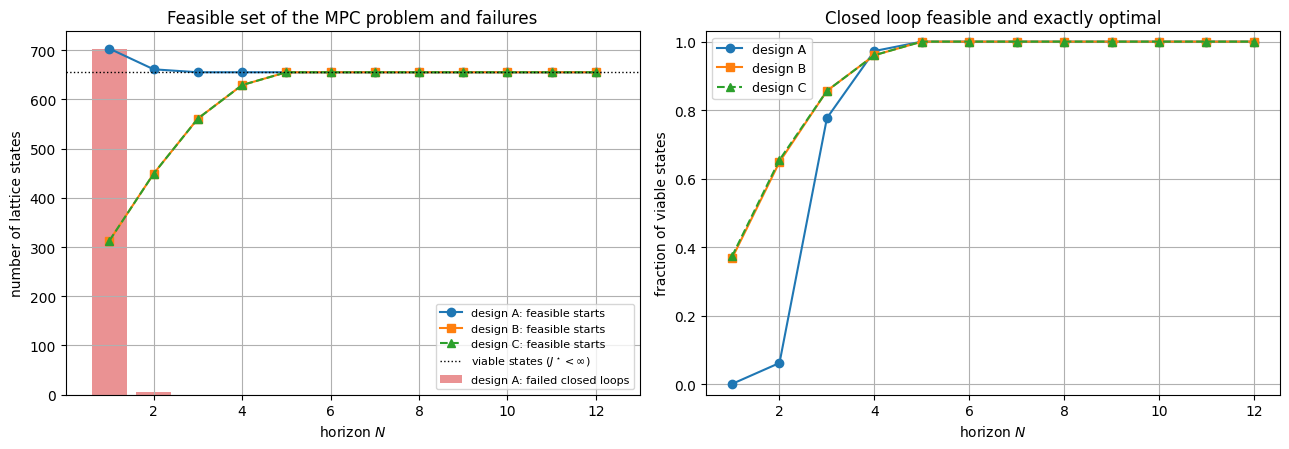

In [9]:
origin4 = int(np.flatnonzero((S4 == 0).all(axis=1))[0])
designs = {"A": np.zeros(n4),
           "B": np.where(in_O, xPx4, np.inf),
           "C": np.where(in_O, J_star4, np.inf)}


def receding_horizon(kappa, F, steps=80):
    """Closed loop of the policy table kappa from every state of F: start states, costs, success flags."""
    start = np.flatnonzero(F)
    s, cost, ok = start.copy(), np.zeros(len(start)), np.ones(len(start), bool)
    for _ in range(steps):
        ok &= F[s]                                      # the MPC problem must be feasible at each visit
        a = kappa[s]
        cost += np.where(ok, q4[s, a], 0.0)
        s_next = succ4[s, a]
        ok &= s_next >= 0
        s = np.where(s_next >= 0, s_next, s)
    return start, cost, ok & (s == origin4)


rows, checks = [], {}
for name, Vf in designs.items():
    J_prev = Vf.copy()                                   # T^{N-1} bar V_f
    upper, mono, bounded = True, True, True
    for N in range(1, 13):
        J_N, a_N = bellman_hard(J_prev)                  # J_N = T^N bar V_f and the MPC law kappa_N
        F = np.isfinite(J_N)
        start, cost, ok = receding_horizon(a_N, F)
        nz = ok & (start != origin4)
        sub = np.maximum(cost[nz] - J_star4[start[nz]], 0.0) / J_star4[start[nz]]   # clip rounding noise
        rows.append(dict(design=name, N=N, feasible=int(F.sum()), doomed=int(np.sum(F & ~fin4)),
                         failed=int(np.sum(~ok)),
                         optimal=int(np.sum(ok & (np.abs(cost - J_star4[start]) < 1e-9))),
                         mean_subopt_pct=100 * sub.mean() if sub.size else np.nan,
                         max_subopt_pct=100 * sub.max() if sub.size else np.nan))
        upper &= bool(np.all(J_N[F] >= J_star4[F] - 1e-9))
        mono &= bool(np.all(J_N <= J_prev + 1e-9))
        bounded &= bool(np.all(cost[ok] <= J_N[start[ok]] + 1e-9))
        J_prev = J_N
    checks[name] = (upper, mono, bounded)

table = pd.DataFrame(rows)
print(table[table.N.isin([1, 2, 3, 4, 5, 8, 12])].to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nviable lattice states (dom J*): {fin4.sum()}")
stay = np.any((succ4 >= 0) & in_O[np.maximum(succ4, 0)], axis=1)
print(f"terminal states with a lattice input that stays in X_f: {np.sum(stay & in_O)} of {in_O.sum()}")
excess = bellman_hard(designs["B"])[0][in_O] - designs["B"][in_O]
print(f"design B: decrease condition V_f >= T V_f fails at {np.sum(excess > 1e-12)} "
      f"of {in_O.sum()} terminal states (largest excess {excess.max():.4f})")
for name, (upper, mono, bounded) in checks.items():
    print(f"design {name}: J_N >= J* for all N: {upper};  J_N nonincreasing in N: {mono};  "
          f"closed-loop cost <= J_N(x_0): {bounded}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for name, style in [("A", "o-"), ("B", "s-"), ("C", "^--")]:
    t = table[table.design == name]
    axes[0].plot(t.N, t.feasible, style, label=f"design {name}: feasible starts")
    axes[1].plot(t.N, t.optimal / fin4.sum(), style, label=f"design {name}")
tA = table[table.design == "A"]
axes[0].bar(tA.N, tA.failed, color="C3", alpha=0.5, label="design A: failed closed loops")
axes[0].axhline(fin4.sum(), color="k", ls=":", lw=1, label=r"viable states ($J^\star<\infty$)")
axes[0].set_xlabel("horizon $N$")
axes[0].set_ylabel("number of lattice states")
axes[0].set_title("Feasible set of the MPC problem and failures")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("horizon $N$")
axes[1].set_ylabel("fraction of viable states")
axes[1].set_title("Closed loop feasible and exactly optimal")
axes[1].set_ylim(-0.03, 1.03)
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

**Reading the result.**

- **A: short horizons fail.** At $N=1$ the optimization sees only $q$ and coasts ($u=0$): the closed
  loop fails from 702 of 703 feasible states, all but the origin. At $N=2$ the 6 doomed feasible
  states fail. From $N=5$ the closed loop is optimal everywhere, but nothing certifies that threshold.
- **B and C: nothing ever fails**, because $\mathcal X_f$ is control invariant on the lattice (all 117
  of its states can stay in it). The feasible set grows through 313, 449, 561 and 629 states to all
  655 at $N=5$, and at $N=1$ the closed loop is already within 0.33% of optimal on average.
- **The guarantees need the decrease condition.** Only C passes the three checks of V.2. Rounding the
  LQR input breaks B's decrease at 114 of 117 terminal states (by at most 0.0432), voiding its
  certificate, yet its closed loops are almost identical to C's.

The terminal **set** buys safety; the terminal **cost** buys performance at short horizons.

## V.4 LMPC learns an upper bound of the value

Notebook 05 stores the realized cost-to-go $J_t^i=\sum_{k\ge t}q(x^i[k],u^i[k])$ of every state
visited in a successful iteration $i$. The visited states form the sampled safe set $SS^j$, and
$V^j(x)=\min\{J_t^i:x^i[t]=x\}$ is the terminal cost on $\mathcal X_f=SS^j$.

1. **Realized costs are upper bounds.** $J_t^i$ is the cost of an admissible trajectory to the
   target, so $V^j\ge J^\star$ on $SS^j$. Data approach $J^\star$ from above; value iteration from
   $J_0=0$ approaches it from below.
2. **The data satisfy the terminal decrease.** If $V^j(x)=J_t^i$, the stored successor
   $x^i[t+1]\in SS^j$ gives
   $V^j(x)=q(x,u^i[t])+J_{t+1}^i\ge q(x,u^i[t])+V^j(x^i[t+1])\ge(T\bar V^j)(x)$.

Fact 2 of V.2 then gives recursive feasibility and a closed-loop cost at most
$J_N(x_S)\le V^j(x_S)$, the previous iteration's cost: **iteration costs never increase**, the main
result of notebook 05 in operator form. On the lattice, LMPC is greedy with respect to
$T^{N-1}\bar V^j$; a sluggish feasible trajectory from $x_S=(-4,0)$ (DP for an energy-dominated cost)
seeds eight iterations for $N=1,2,3$.

J*(x_S) = 34.500;  seed: 10 steps, cost 66.456
N = 1: iteration costs [66.456 66.456 66.456 66.456 66.456 66.456 66.456 66.456 66.456];  never increases: True;  final gap to J*: 92.6%
N = 2: iteration costs [66.456 38.369 38.369 38.369 38.369 38.369 38.369 38.369 38.369];  never increases: True;  final gap to J*: 11.2%
N = 3: iteration costs [66.456 34.5   34.5   34.5   34.5   34.5   34.5   34.5   34.5  ];  never increases: True;  final gap to J*: 0.0%
smallest stored J^j_t - J*(x^j[t]) over all runs and iterations: 0.00e+00
N = 3, iteration 1: max |J^1_t - J*(x^1[t])| = 0.00e+00


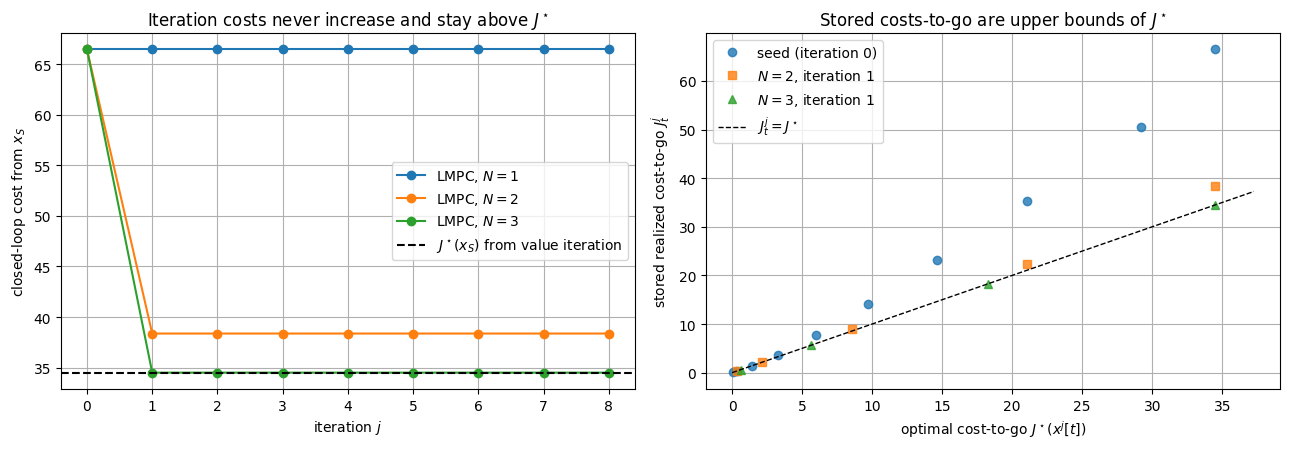

In [10]:
def rollout(policy, s0, max_steps=200):
    """Closed loop of a policy table from state s0 until the origin: visited states and inputs."""
    states, acts = [s0], []
    while states[-1] != origin4 and len(acts) < max_steps:
        a = int(policy[states[-1]])
        acts.append(a)
        states.append(int(succ4[states[-1], a]))
        assert states[-1] >= 0, "left the state constraints"
    return np.array(states), np.array(acts)


s_start = int(np.flatnonzero(np.all(S4 == [-4.0, 0.0], axis=1))[0])
q_lazy = np.where(succ4 >= 0, 0.005 * xQx[:, None] + U4[None, :] ** 2, np.inf)   # sluggish seed cost
J = np.zeros(n4)
for _ in range(10000):
    J_new = (q_lazy + J[np.maximum(succ4, 0)]).min(axis=1)
    if np.array_equal(J_new, J):
        break
    J = J_new
seed = rollout((q_lazy + J[np.maximum(succ4, 0)]).argmin(axis=1), s_start)

lmpc_costs, samples, gaps = {}, [], []
for N_L in [1, 2, 3]:
    V = np.full(n4, np.inf)
    V[origin4] = 0.0                                     # sampled value function V^j on SS^j
    states, acts = seed
    costs = []
    for j in range(9):
        ctg = np.cumsum(q4[states[:-1], acts][::-1])[::-1]     # realized costs-to-go J^j_t
        costs.append(ctg[0])
        gaps.append(np.min(ctg - J_star4[states[:-1]]))
        if (N_L, j) in [(2, 0), (2, 1), (3, 1)]:
            samples.append((N_L, j, J_star4[states[:-1]], ctg))
        V[states[:-1]] = np.minimum(V[states[:-1]], ctg)
        J_tilde = V.copy()                               # T^{N_L - 1} bar V^j
        for _ in range(N_L - 1):
            J_tilde, _ = bellman_hard(J_tilde)
        states, acts = rollout(bellman_hard(J_tilde)[1], s_start)
    lmpc_costs[N_L] = np.array(costs)

print(f"J*(x_S) = {J_star4[s_start]:.3f};  seed: {len(seed[1])} steps, cost {lmpc_costs[1][0]:.3f}")
for N_L, c in lmpc_costs.items():
    print(f"N = {N_L}: iteration costs {np.round(c, 3)};  never increases: {bool(np.all(np.diff(c) <= 1e-9))};  "
          f"final gap to J*: {100 * (c[-1] / J_star4[s_start] - 1):.1f}%")
print(f"smallest stored J^j_t - J*(x^j[t]) over all runs and iterations: {min(gaps):.2e}")
print(f"N = 3, iteration 1: max |J^1_t - J*(x^1[t])| = {np.max(np.abs(samples[2][3] - samples[2][2])):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for N_L, c in lmpc_costs.items():
    axes[0].plot(np.arange(len(c)), c, "o-", label=f"LMPC, $N={N_L}$")
axes[0].axhline(J_star4[s_start], color="k", ls="--", label=r"$J^\star(x_S)$ from value iteration")
axes[0].set_xlabel("iteration $j$")
axes[0].set_ylabel(r"closed-loop cost from $x_S$")
axes[0].set_title("Iteration costs never increase and stay above $J^\\star$")
axes[0].legend()
names = {(2, 0): "seed (iteration 0)", (2, 1): "$N=2$, iteration 1", (3, 1): "$N=3$, iteration 1"}
for (N_L, j, js, ctg), mk in zip(samples, ["o", "s", "^"]):
    axes[1].plot(js, ctg, mk, ms=6, alpha=0.8, label=names[(N_L, j)])
lim = max(s[2].max() for s in samples) * 1.08
axes[1].plot([0, lim], [0, lim], "k--", lw=1, label=r"$J_t^j=J^\star$")
axes[1].set_xlabel(r"optimal cost-to-go $J^\star(x^j[t])$")
axes[1].set_ylabel(r"stored realized cost-to-go $J_t^j$")
axes[1].set_title("Stored costs-to-go are upper bounds of $J^\\star$")
axes[1].legend()
plt.tight_layout()
plt.show()

**Reading the result.** The seed costs 66.456, 92.6% above $J^\star(x_S)=34.500$. Iteration costs
never increase, and no stored cost-to-go lies below $J^\star$ (the smallest difference is exactly 0).
The horizon decides how much of the data is usable. With $N=1$ nothing beats replaying the seed. With
$N=2$ the cost stalls at 38.369, 11.2% above $J^\star$. With $N=3$ the first iteration is optimal and
its stored costs-to-go lie on the diagonal: the principle of optimality, visible in the data.
Improvement is guaranteed, optimality is not; the convexified safe set of notebook 05 gives short
horizons more room.

<a id="part-6"></a>
# Part VI — Model-free: Q-functions and Q-learning

So far the model was used either to tabulate $J$ or to predict over a horizon. RL works from sampled
transitions. The vocabulary differs, but the objects do not:

| Control | Reinforcement learning |
|---|---|
| plant, controller $\mu$ | environment, agent with policy $\pi$ |
| input $u$ | action $a$ |
| stage cost $q(x,u)$ | negative reward $-r$ |
| cost-to-go $J$ (minimized) | value $V=-J$ (maximized) |
| state-input cost-to-go $Q$ | action-value $Q$ |
| system identification | model learning |

## VI.1 The Q-function

$$
Q^\star(x,u)=q(x,u)+\gamma J^\star\big(f(x,u)\big),
\qquad
J^\star(x)=\min_uQ^\star(x,u),
\qquad
\mu^\star(x)\in\arg\min_uQ^\star(x,u).
$$

With $Q^\star$ in hand, **acting optimally needs no model**, only a minimization over inputs.
Substituting $J^\star=\min_{u'}Q^\star(\cdot,u')$ into the definition gives the **Bellman equation
for $Q$**, $Q^\star(x,u)=q(x,u)+\gamma\min_{u'}Q^\star(f(x,u),u')=:(FQ^\star)(x,u)$, and $F$ is a
$\gamma$-contraction by the proof of III.2.

## VI.2 Tabular Q-learning

After observing a transition $(x,u,c,x^+)$ of the real system,

$$
Q(x,u)\leftarrow Q(x,u)+\alpha\Big[c+\gamma\min_{u'}Q(x^+,u')-Q(x,u)\Big].
$$

The bracket is the **temporal-difference error**; its target is a sample of $(FQ)(x,u)$ (exact for
deterministic transitions) and just $c$ after a crash. **Convergence** (Watkins and Dayan, 1992;
Tsitsiklis, 1994): with finite sets, bounded costs and $\gamma<1$, if every pair is updated
infinitely often with step sizes satisfying $\sum_t\alpha_t=\infty$ and $\sum_t\alpha_t^2<\infty$,
then $Q\to Q^\star$ with probability one, as for a noisy, asynchronous iteration of $F$.
**Exploration** is thus an assumption, met by $\varepsilon$-greedy inputs or by optimistic
initialization ($Q_0=0$ lies below every $Q^\star$ here, so untried inputs look attractive). Learning
is **off-policy**: the limit is $Q^\star$ whatever policy generated the data.

## VI.3 Q-learning on the lattice

The learner faces the problem of Part III but only sees transitions. Episodes start at random states,
a luxury that real systems rarely allow, and end after 30 steps or at a crash. The score is the
fraction of the 171 viable states at which the greedy input is optimal.

                     alpha=1, eps=0.1: all optimal from step  40000 (crashes so far  972);  final fraction 1.000;  crashes 2776;  viable states whose greedy input crashes: 0
                   alpha=0.1, eps=0.1: all optimal from step never;  final fraction 0.930;  crashes 3900;  viable states whose greedy input crashes: 0
               alpha=1/n^0.6, eps=0.1: all optimal from step  68000 (crashes so far 1269);  final fraction 1.000;  crashes 2782;  viable states whose greedy input crashes: 0


    alpha=1, eps=0, Q0=0 (optimistic): all optimal from step  52000 (crashes so far  926);  final fraction 1.000;  crashes 2131;  viable states whose greedy input crashes: 0
 alpha=1, eps=0, Q0=200 (pessimistic): all optimal from step never;  final fraction 0.327;  crashes 70217;  viable states whose greedy input crashes: 29

alpha=1, eps=0.1 after 200000 steps: max |Q - Q*| on (viable state, optimal input) = 0.00e+00;  over all pairs = 95.0
model-based value iteration: greedy policy optimal after 6 sweeps = 6450 Bellman backups over all 1075 state-input pairs


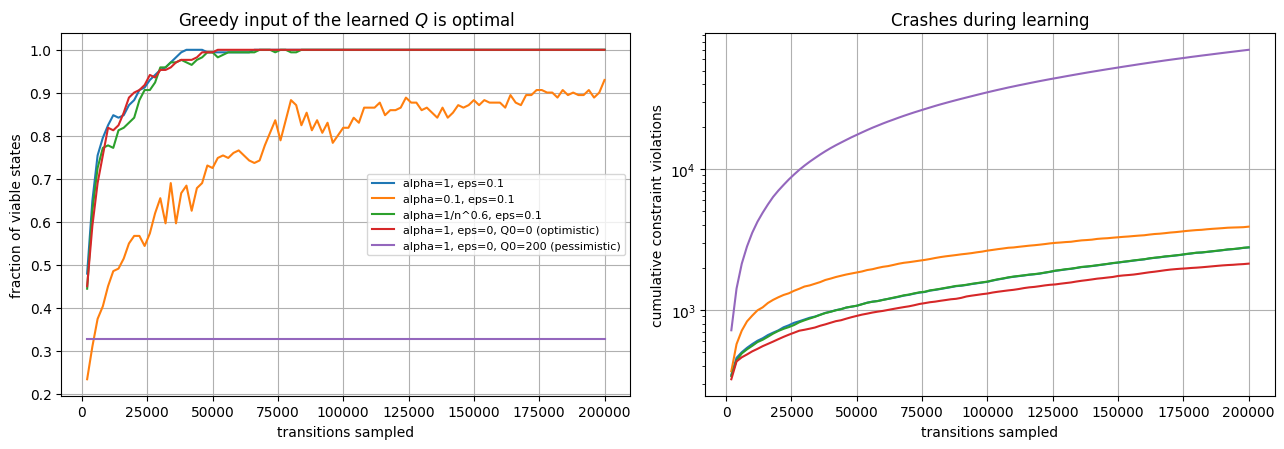

In [11]:
def q_learning(n_steps, alpha, eps, Q0=0.0, horizon=30, seed=0, every=2000):
    """Tabular Q-learning on the crash problem of Part III; alpha is a number or the string '1/n^0.6'."""
    rng = np.random.default_rng(seed)
    explore = rng.random(n_steps) < eps
    rand_a = rng.integers(m3, size=n_steps)
    starts = rng.integers(n3, size=n_steps)
    Qtab = [[Q0] * m3 for _ in range(n3)]                # plain lists: fast scalar updates
    visits = [[0] * m3 for _ in range(n3)]
    succ_l, cost_l = succ3.tolist(), cost_c[:n3].tolist()
    s, t_ep, crashes, log = int(starts[0]), 0, 0, []
    for t in range(n_steps):
        row = Qtab[s]
        a = int(rand_a[t]) if explore[t] else row.index(min(row))
        s2, c = succ_l[s][a], cost_l[s][a]
        target = c if s2 < 0 else c + gamma * min(Qtab[s2])
        visits[s][a] += 1
        step = visits[s][a] ** -0.6 if alpha == "1/n^0.6" else alpha
        row[a] += step * (target - row[a])
        crashes += s2 < 0
        t_ep += 1
        if s2 < 0 or t_ep == horizon:
            s, t_ep = int(starts[t]), 0
        else:
            s = s2
        if (t + 1) % every == 0:
            greedy = np.argmin(np.array(Qtab), axis=1)
            log.append((t + 1, opt_action3[np.arange(n3), greedy][viable3].mean(), crashes))
    return np.array(Qtab), np.array(log)


configs = [("alpha=1, eps=0.1", dict(alpha=1.0, eps=0.1)),
           ("alpha=0.1, eps=0.1", dict(alpha=0.1, eps=0.1)),
           ("alpha=1/n^0.6, eps=0.1", dict(alpha="1/n^0.6", eps=0.1)),
           ("alpha=1, eps=0, Q0=0 (optimistic)", dict(alpha=1.0, eps=0.0, Q0=0.0)),
           ("alpha=1, eps=0, Q0=200 (pessimistic)", dict(alpha=1.0, eps=0.0, Q0=200.0))]
n_steps = 200_000
logs = {}
for name, cfg in configs:
    Qtab, log = q_learning(n_steps, **cfg)
    logs[name] = log
    hit = np.flatnonzero(log[:, 1] == 1.0)
    first = f"{int(log[hit[0], 0]):>6d} (crashes so far {int(log[hit[0], 2]):>4d})" if hit.size else "never"
    greedy_crash = int(np.sum((succ3[np.arange(n3), Qtab.argmin(axis=1)] < 0)[viable3]))
    print(f"{name:>37}: all optimal from step {first};  final fraction {log[-1, 1]:.3f};  "
          f"crashes {int(log[-1, 2])};  viable states whose greedy input crashes: {greedy_crash}")
    if name == configs[0][0]:
        Q_first = Qtab

best = Q_star3[:n3].argmin(axis=1)
err_best = np.abs(Q_first[np.arange(n3), best] - Q_star3[np.arange(n3), best])[viable3]
print(f"\nalpha=1, eps=0.1 after {n_steps} steps: max |Q - Q*| on (viable state, optimal input) = "
      f"{err_best.max():.2e};  over all pairs = {np.abs(Q_first - Q_star3[:n3]).max():.1f}")
print(f"model-based value iteration: greedy policy optimal after 6 sweeps = "
      f"{6 * n3 * m3} Bellman backups over all {n3 * m3} state-input pairs")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for name, log in logs.items():
    axes[0].plot(log[:, 0], log[:, 1], label=name)
    axes[1].semilogy(log[:, 0], np.maximum(log[:, 2], 1), label=name)
axes[0].set_xlabel("transitions sampled")
axes[0].set_ylabel("fraction of viable states")
axes[0].set_title("Greedy input of the learned $Q$ is optimal")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("transitions sampled")
axes[1].set_ylabel("cumulative constraint violations")
axes[1].set_title("Crashes during learning")
plt.tight_layout()
plt.show()

**Reading the result.**

- **Samples instead of a model.** With $\alpha=1$ (exact for deterministic transitions) and
  $\varepsilon=0.1$, the greedy policy is optimal everywhere after 40,000 transitions and 972 crashes.
  Value iteration needed 6 sweeps (6,450 backups) and no crash.
- **Step sizes.** The decaying $\alpha=n^{-0.6}$ needs 68,000 transitions; the constant $\alpha=0.1$
  is still at 93% after 200,000.
- **Initialization is a form of exploration.** With $\varepsilon=0$, the optimistic $Q_0=0$ succeeds
  (52,000 transitions). The pessimistic $Q_0=200$ fails: a crash target is only its cost (at most
  118), while other targets bootstrap from successors still valued near 200. Crashing looks cheap,
  with 70,217 crashes, a score stuck at 0.327, and a greedy input that crashes from 29 viable states.
- **Accurate only where it matters.** After the first run, $Q=Q^\star$ at the optimal input of every
  viable state, while other pairs are off by up to 95.0.

## VI.4 Function approximation and DQN

DQN (Mnih et al., 2015) replaces the table by a network $Q_\theta$ over a finite input set and
minimizes the squared temporal-difference error

$$
\mathcal L(\theta)=\mathbb E_{(x,u,c,x^+)\sim\mathcal D}
\Big[\big(c+\gamma\min_{u'}Q_{\theta^-}(x^+,u')-Q_\theta(x,u)\big)^2\Big].
$$

The **replay buffer** $\mathcal D$ decorrelates the samples and reuses costly data. The **target
network** $\theta^-$, refreshed only occasionally, makes each phase a regression toward a fixed
target.

**Why the contraction argument no longer applies.** With exact regressions, DQN would iterate
$Q_{k+1}=\Pi FQ_k$, where $\Pi$ projects onto the network class in a norm weighted by the replay
distribution. $F$ contracts in the sup-norm, but $\Pi$ is non-expansive only in its weighted $L^2$
norm, so $\Pi F$ need not contract in any norm; with bootstrapping and off-policy data, divergence is
possible (Tsitsiklis and Van Roy, 1997). The minimum over noisy estimates is also biased low, which
double Q-learning corrects. Part III says what is approximated, not that the approximation converges.

**Compared with MPC and LMPC**, DQN learns a global $Q$ and meets constraints only through penalties,
by violating them. MPC keeps the model, enforces constraints online, and needs only a local tail
approximation, which LMPC learns from its own data as a guaranteed upper bound.

<a id="part-7"></a>
# Part VII — Common pitfalls

## VII.1 Pitfall: the contraction proof covers MPC

The proof needs bounded costs and $\gamma<1$; MPC is undiscounted, with $+\infty$ constraint costs.
There, value iteration rests on monotonicity (IV.1) and stability on the terminal decrease (V.2).

## VII.2 Pitfall: a long horizon without terminal ingredients is a safe default

$T^N0$ underestimates $J^\star$, and its domain contains doomed states (48 at $N=1$, 6 at $N=2$ in
V.3). It works eventually, but nothing certifies when.

## VII.3 Pitfall: a terminal cost valid for the model is valid for the implementation

$x^\top Px$ on $\mathcal O_\infty$ is exact for the continuous LQ problem, but restricting the inputs
broke its decrease condition at 114 of 117 states (V.3).

## VII.4 Pitfall: finite cost and control invariance are the same thing

$\operatorname{dom}J^\star\subseteq\mathcal C_\infty$, but equality also needs every viable state to
reach the target. For $x^+=2x+u$ with integer $|x|\le10$ and $u\in\{-3,\ldots,3\}$, the state 3 can
stay put ($u=-3$) but never goes lower: it is viable, yet its cost is infinite when $q>0$ away from
the origin.

## VII.5 Pitfall: LMPC's terminal cost is a Q-function

Parts of the LMPC literature write it as $Q^j(x)$, but it is a state function, an upper bound of
$J^\star$ built from realized costs. An RL $Q$-function depends on state and input and is learned by
bootstrapping.

## VII.6 Pitfall: a penalty is a constraint

A penalty leaves the optimal policy unchanged only if it is large enough (checked in Part III), and a
learner respects it only after violating it: 972 crashes before the policy of VI.3 became optimal.

<a id="part-8"></a>
# Part VIII — Check your understanding

Try answering each question before opening the answer.

### Q1. State the principle of optimality. What does its proof use?

<details><summary>Answer</summary>

The tail of an optimal input sequence is optimal for the tail problem from the state it reaches. The
proof splices a cheaper tail onto the optimal head; this needs an additive cost, a state that
summarizes the past, and constraints that act stage by stage.

</details>

### Q2. Why is the controllable-set recursion of notebook 02 a special case of DP?

<details><summary>Answer</summary>

With constraints as infinite costs, the Bellman step maps a function with domain $\mathcal S$ to one
with domain $\mathcal X\cap\operatorname{Pre}(\mathcal S)$. For functions with values in
$\{0,+\infty\}$, the DP recursion *is* the set recursion.

</details>

### Q3. In the LQ problem, why does a matrix recursion suffice, and what sets its convergence rate?

<details><summary>Answer</summary>

Minimizing a strictly convex quadratic in $u$ leaves a quadratic in $x$, so $J_k=x^\top P_kx$ for
all $k$. The sandwich inequality shows that the closed loop propagates the error, at the asymptotic
rate $\rho(A_{\mathrm{cl}})^2$ per step.

</details>

### Q4. Which assumptions make the Bellman operator a contraction, and where do they enter?

<details><summary>Answer</summary>

Bounded costs keep $TJ$ bounded and $\|J-J'\|_\infty$ finite. The factor $\gamma<1$ enters through
the constant shift $T(J+c\mathbf 1)=TJ+\gamma c\mathbf 1$, which together with monotonicity is the
whole proof. With $\gamma=1$, $T$ is only non-expansive.

</details>

### Q5. Why does policy iteration terminate on a finite problem?

<details><summary>Answer</summary>

Each improvement gives $J_{\mu_{k+1}}\le J_{\mu_k}$, strictly at some state whenever an action
changes, so no policy repeats and there are finitely many. When nothing changes,
$TJ_{\mu_k}=J_{\mu_k}$, hence $J_{\mu_k}=J^\star$.

</details>

### Q6. Describe MPC in DP terms. Why does $V_f=x^\top Px$ on $\mathcal O_\infty$ allow a short horizon?

<details><summary>Answer</summary>

MPC is greedy with respect to $T^{N-1}\bar V_f$, evaluated at the current state. If $V_f=J^\star$ on
$\mathcal X_f$, as $x^\top Px$ is on $\mathcal O_\infty$ for the constrained LQ problem, then
$T^N\bar V_f=J^\star$ wherever an optimal trajectory enters $\mathcal X_f$ within $N$ steps. The
decrease $\bar V_f\ge T\bar V_f$ then gives recursive feasibility and a Lyapunov function.

</details>

### Q7. Why are LMPC's stored costs-to-go upper bounds of $J^\star$, and why does that matter?

<details><summary>Answer</summary>

Each is the realized cost of an admissible trajectory to the target, so it is at least optimal. Each
also comes with a stored feasible continuation, so $\bar V^j\ge T\bar V^j$, which yields recursive
feasibility and non-increasing iteration costs. A lower bound such as $T^N0$ gives neither.

</details>

### Q8. What does a DQN target network do, and why does the tabular convergence proof not carry over?

<details><summary>Answer</summary>

It freezes the parameters used in the targets, so each phase is a regression toward a fixed target.
With function approximation the update is $\Pi F$, and since $\Pi$ is non-expansive only in a
weighted $L^2$ norm, $\Pi F$ need not contract and can diverge.

</details>

<a id="part-9"></a>
# Part IX — Summary and references

**Summary.**

- **DP** gives $J_k=\min_u\{\bar q(x,u)+J_{k+1}(f(x,u))\}$, $J_N=\bar V_f$, for any model and cost;
  the set recursions of notebook 02 are its $\{0,\infty\}$-valued case. In the LQ case it is the
  Riccati recursion, which converges at the rate $\rho(A_{\mathrm{cl}})^2$.
- **With bounded costs and $\gamma<1$**, $T$ is a sup-norm contraction: value iteration converges at
  the tight rate $\gamma^k$, and policy iteration stops after a few improvements (4 here).
- **On the constrained double integrator**, value iteration reproduced the sets of notebook 02 state
  for state; tabulation breaks down within a handful of dimensions.
- **MPC** is greedy with respect to $T^{N-1}\bar V_f$, and $\bar V_f\ge T\bar V_f$ is its stability
  proof. **LMPC**'s realized costs-to-go are upper bounds of $J^\star$ that satisfy it automatically.
- **Q-learning** trades the model for exploration and samples (40,000 transitions and 972 crashes
  against 6,450 backups); **DQN** loses the contraction guarantee.

| Method | Computes | Where | Uses the model | Guarantees come from |
|---|---|---|---|---|
| DP (VI, PI) | $J^\star$ and $\mu^\star$ exactly | every state, offline | yes | contraction or monotonicity |
| MPC | greedy policy of $T^{N-1}\bar V_f$ | current state, online | yes | terminal set and decrease |
| LMPC | MPC with $V_f$ from realized costs | current state, online | yes | data satisfy the decrease |
| Q-learning | $Q^\star$ from samples | visited pairs | no | stochastic approximation |
| DQN | $Q_\theta\approx Q^\star$ | wherever the network generalizes | no | no general guarantee |

**Scope.** Deterministic, discrete-time problems; with noise, $J(f(x,u))$ becomes an expectation and
MPC needs robust or stochastic formulations.

**References.**

- R. Bellman, *Dynamic Programming*, Princeton University Press, 1957.
- D. P. Bertsekas, *Dynamic Programming and Optimal Control*, Athena Scientific, Vol. I (4th ed.,
  2017) and Vol. II (4th ed., 2012).
- R. S. Sutton and A. G. Barto, *Reinforcement Learning: An Introduction*, 2nd ed., MIT Press, 2018.
- C. J. C. H. Watkins and P. Dayan, "Q-learning", *Machine Learning*, 8, 279–292, 1992.
- J. N. Tsitsiklis, "Asynchronous stochastic approximation and Q-learning", *Machine Learning*, 16,
  185–202, 1994.
- J. N. Tsitsiklis and B. Van Roy, "An analysis of temporal-difference learning with function
  approximation", *IEEE Transactions on Automatic Control*, 42(5), 674–690, 1997.
- H. van Hasselt, "Double Q-learning", *Advances in Neural Information Processing Systems* 23, 2010.
- V. Mnih et al., "Human-level control through deep reinforcement learning", *Nature*, 518, 529–533,
  2015.
- U. Rosolia and F. Borrelli, "Learning Model Predictive Control for Iterative Tasks. A Data-Driven
  Control Framework", *IEEE Transactions on Automatic Control*, 63(7), 1883–1896, 2018.